<a href="https://colab.research.google.com/github/Lawson-Dong/SINDy_code_reproduction/blob/main/DSINDy_testing_different_kinds_of_noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


CORRECTED EXPERIMENT: FAIR COMPARISON WITH NUMERICAL STABILITY FIXES

FIXES APPLIED:
- Added NaN/Inf checking and interpolation
- Safe pseudoinverse with fallback
- Integration explosion detection
- Graceful error handling

FAIR COMPARISON: SINDy vs DSINDy
Both methods evaluated on state reconstruction quality

Time series: 2000 points, dt = 0.0100
Trials per condition: 3
Noise levels: ['1%', '5%', '10%', '15%', '20%', '25%']

Testing GAUSSIAN Noise
  Noise:    1% | SINDy: 11.9495 | DSINDy: 7.6539 | Coef S/D: 0.245/6.136
  Noise:    5% | SINDy: 12.7129 | DSINDy: 7.6940 | Coef S/D: 0.938/6.240
  Noise:   10% | SINDy: 13.3025 | DSINDy: 7.5783 | Coef S/D: 2.428/6.432
  Noise:   15% | SINDy: 13.3040 | DSINDy: 7.6754 | Coef S/D: 3.427/6.164
  Noise:   20% | SINDy: 12.1219 | DSINDy: 7.5548 | Coef S/D: 4.305/7.180
  Noise:   25% | SINDy: 13.4198 | DSINDy: 7.6027 | Coef S/D: 4.565/6.091

Testing LAPLACE Noise
  Noise:    1% | SINDy: 12.0608 | DSINDy: 7.5014 | Coef S/D: 0.231/6.135
  Noise:   

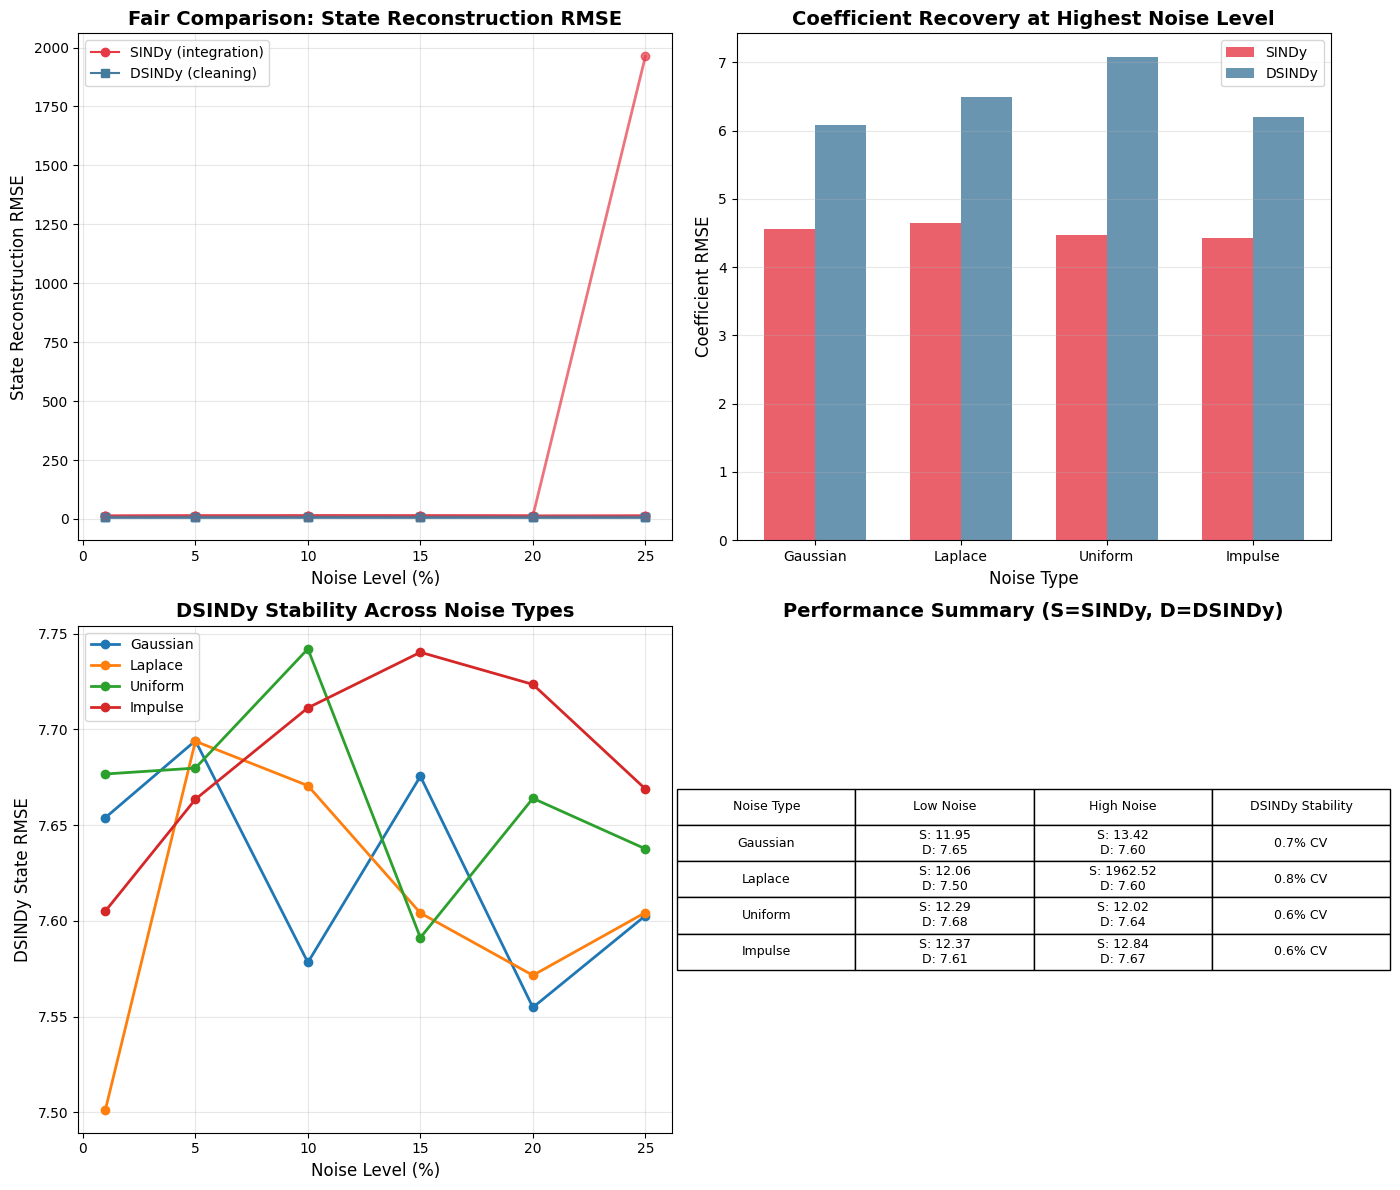


EXPERIMENT SUMMARY

Key Findings with Fair Evaluation:
--------------------------------------------------

Gaussian Noise:
  Low noise (1%):  SINDy=11.949, DSINDy=7.654
  High noise (25%): SINDy=13.420, DSINDy=7.603

Laplace Noise:
  Low noise (1%):  SINDy=12.061, DSINDy=7.501
  High noise (25%): SINDy=1962.520, DSINDy=7.604

Uniform Noise:
  Low noise (1%):  SINDy=12.288, DSINDy=7.677
  High noise (25%): SINDy=12.025, DSINDy=7.638

Impulse Noise:
  Low noise (1%):  SINDy=12.369, DSINDy=7.605
  High noise (25%): SINDy=12.842, DSINDy=7.669

EXPERIMENT COMPLETED


In [5]:
# Install required libraries
!pip install scikit-learn

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
from scipy.linalg import pinv
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# Lorenz System Definition
# ============================================================================
def lorenz_system(state, t, sigma=10, rho=28, beta=8/3):
    """Derivatives for the Lorenz system"""
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

def generate_true_data(n_points=2000, t_max=20):
    """Generates a true trajectory of the Lorenz system"""
    t = np.linspace(0, t_max, n_points)
    initial_state = [-8, 7, 27]
    true_states = odeint(lorenz_system, initial_state, t, rtol=1e-12, atol=1e-12)
    return t, true_states

# ============================================================================
# Noise Generation Functions (Non-Gaussian)
# ============================================================================
def add_gaussian_noise(true_states, noise_level):
    """Add Gaussian noise to the data"""
    noisy_states = true_states.copy()
    for i in range(3):
        std = np.std(true_states[:, i])
        noise = np.random.normal(0, noise_level * std, true_states[:, i].shape)
        noisy_states[:, i] += noise
    return noisy_states

def add_laplace_noise(true_states, noise_level):
    """Add Laplace (double exponential) noise to the data"""
    noisy_states = true_states.copy()
    for i in range(3):
        std = np.std(true_states[:, i])
        scale = noise_level * std / np.sqrt(2)
        noise = np.random.laplace(0, scale, true_states[:, i].shape)
        noisy_states[:, i] += noise
    return noisy_states

def add_uniform_noise(true_states, noise_level):
    """Add Uniform noise to the data"""
    noisy_states = true_states.copy()
    for i in range(3):
        std = np.std(true_states[:, i])
        half_width = np.sqrt(3) * noise_level * std
        noise = np.random.uniform(-half_width, half_width, true_states[:, i].shape)
        noisy_states[:, i] += noise
    return noisy_states

def add_impulse_noise(true_states, noise_level, impulse_prob=0.05):
    """Add Impulse (salt-and-pepper) noise to the data"""
    noisy_states = true_states.copy()
    for i in range(3):
        std = np.std(true_states[:, i])
        mask = np.random.random(true_states[:, i].shape) < impulse_prob
        impulse_magnitude = (3 + 2 * np.random.random(int(mask.sum()))) * noise_level * std
        impulse_sign = np.random.choice([-1, 1], int(mask.sum()))
        noise = np.zeros(true_states[:, i].shape)
        noise[mask] = impulse_sign * impulse_magnitude
        noisy_states[:, i] += noise
    return noisy_states

# ============================================================================
# Utility Functions
# ============================================================================
def check_and_fix_nan(data, name="data"):
    """Check for NaN and replace with interpolation if found"""
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
        print(f"  Warning: NaN/Inf found in {name}, attempting to fix...")
        fixed_data = data.copy()
        for i in range(data.shape[1]):
            col = fixed_data[:, i]
            mask = np.isnan(col) | np.isinf(col)
            if np.any(mask):
                # Replace with linear interpolation
                x = np.arange(len(col))
                valid = ~mask
                if np.sum(valid) > 1:
                    col[mask] = np.interp(x[mask], x[valid], col[valid])
                else:
                    col[mask] = 0
            fixed_data[:, i] = col
        return fixed_data
    return data

# ============================================================================
# SINDy Implementation
# ============================================================================
class SINDy:
    """Traditional SINDy algorithm"""
    def __init__(self, poly_degree=2, threshold=0.1, include_bias=False):
        self.poly_degree = poly_degree
        self.threshold = threshold
        self.include_bias = include_bias
        self.coefficients = None
        self.poly = PolynomialFeatures(degree=poly_degree, include_bias=include_bias)

    def compute_derivatives(self, x, dt):
        """Compute derivatives using finite differences"""
        derivatives = np.zeros_like(x)
        # Central difference for interior points
        derivatives[1:-1] = (x[2:] - x[:-2]) / (2 * dt)
        # Forward difference for first point
        derivatives[0] = (x[1] - x[0]) / dt
        # Backward difference for last point
        derivatives[-1] = (x[-1] - x[-2]) / dt
        return derivatives

    def fit(self, x, dt):
        """Fit the SINDy model"""
        # Check for NaN in input
        x = check_and_fix_nan(x, "SINDy input")

        x_dot = np.array([self.compute_derivatives(x[:, i], dt) for i in range(3)]).T
        Theta = self.poly.fit_transform(x)

        coefficients = []
        for i in range(3):
            lasso = Lasso(alpha=self.threshold, fit_intercept=False, max_iter=10000)
            lasso.fit(Theta, x_dot[:, i])
            coef = lasso.coef_
            coef[np.abs(coef) < self.threshold] = 0
            coefficients.append(coef)

        self.coefficients = np.array(coefficients)
        return self.coefficients

    def predict_derivative(self, x):
        """Predict derivatives at given states"""
        x = check_and_fix_nan(x, "SINDy predict input")
        Theta = self.poly.fit_transform(x)
        return Theta @ self.coefficients.T

    def reconstruct_states(self, x0, t):
        """Reconstruct states by integrating the learned dynamics"""
        dt = t[1] - t[0]
        n_steps = len(t)
        n_dims = len(x0)

        states = np.zeros((n_steps, n_dims))
        states[0] = x0

        for i in range(1, n_steps):
            try:
                # Predict derivative at current state
                current_state = states[i-1:i]
                current_state = check_and_fix_nan(current_state, f"SINDy state at step {i}")

                dx = self.predict_derivative(current_state)[0]

                # Check for explosion
                if np.any(np.abs(dx) > 1e6):
                    print(f"  Warning: SINDy integration exploding at step {i}")
                    # Use last good state
                    states[i] = states[i-1]
                    continue

                # Euler integration
                states[i] = states[i-1] + dx * dt

                # Check for NaN
                if np.any(np.isnan(states[i])) or np.any(np.isinf(states[i])):
                    states[i] = states[i-1]

            except Exception as e:
                print(f"  Warning: SINDy integration error at step {i}: {e}")
                states[i] = states[i-1]

        return states

# ============================================================================
# DSINDy Implementation
# ============================================================================
class DSINDy:
    """Derivative-based SINDy (DSINDy)"""
    def __init__(self, poly_degree=2, threshold=0.1, alpha=0.5, max_iter=15, include_bias=False):
        self.poly_degree = poly_degree
        self.threshold = threshold
        self.alpha = alpha
        self.max_iter = max_iter
        self.include_bias = include_bias
        self.coefficients = None
        self.poly = PolynomialFeatures(degree=poly_degree, include_bias=include_bias)

    def compute_integrator_matrix(self, N, dt):
        """Construct the integrator matrix T (trapezoidal rule)"""
        T = np.zeros((N, N))
        for i in range(1, N):
            T[i, 0] = dt / 2
            for j in range(1, i):
                T[i, j] = dt
            T[i, i] = dt / 2
        return T

    def safe_pinv(self, matrix, rcond=1e-10):
        """Safe pseudoinverse with fallback"""
        try:
            return pinv(matrix, rcond=rcond)
        except:
            # Fallback to numpy's pinv with higher tolerance
            return np.linalg.pinv(matrix, rcond=1e-6)

    def clean_data_via_projection(self, u, dt):
        """Clean data via projection (IterPSDN) with stability checks"""
        N = len(u)
        u = check_and_fix_nan(u, "DSINDy input")

        T = self.compute_integrator_matrix(N, dt)
        u_clean = u.copy()
        u_clean_prev = u_clean.copy()

        for iteration in range(self.max_iter):
            try:
                u_clean = check_and_fix_nan(u_clean, f"DSINDy iteration {iteration}")

                Theta = self.poly.fit_transform(u_clean)
                Theta = check_and_fix_nan(Theta, f"Theta iteration {iteration}")

                ones = np.ones((N, 1))
                Phi = np.hstack([ones, T @ Theta])
                Phi = check_and_fix_nan(Phi, f"Phi iteration {iteration}")

                # Use safe pseudoinverse
                Phi_pinv = self.safe_pinv(Phi)
                P = Phi @ Phi_pinv

                # Apply projection
                u_new = P @ u
                u_new = check_and_fix_nan(u_new, f"u_new iteration {iteration}")

                # Relaxed update
                u_clean_new = self.alpha * u_new + (1 - self.alpha) * u_clean

                # Check for convergence
                if iteration > 0:
                    change = np.linalg.norm(u_clean_new - u_clean_prev) / (np.linalg.norm(u_clean_prev) + 1e-10)
                    if change < 1e-6:
                        u_clean = u_clean_new
                        break

                u_clean_prev = u_clean.copy()
                u_clean = u_clean_new

            except Exception as e:
                print(f"  Warning: DSINDy iteration {iteration} failed: {e}")
                continue

        return u_clean

    def compute_derivatives(self, x, dt):
        """Compute derivatives using finite differences"""
        x = check_and_fix_nan(x, "DSINDy derivative input")
        derivatives = np.zeros_like(x)
        derivatives[1:-1] = (x[2:] - x[:-2]) / (2 * dt)
        derivatives[0] = (x[1] - x[0]) / dt
        derivatives[-1] = (x[-1] - x[-2]) / dt
        return derivatives

    def fit(self, u_noisy, dt):
        """Fit the DSINDy model"""
        # Clean data
        self.u_clean = self.clean_data_via_projection(u_noisy, dt)
        self.u_clean = check_and_fix_nan(self.u_clean, "DSINDy cleaned data")

        # Compute derivatives
        u_clean_dot = np.array([self.compute_derivatives(self.u_clean[:, i], dt) for i in range(3)]).T
        u_clean_dot = check_and_fix_nan(u_clean_dot, "DSINDy derivatives")

        # Build library matrix
        Theta_clean = self.poly.fit_transform(self.u_clean)

        # Sparse regression
        coefficients = []
        for i in range(3):
            lasso = Lasso(alpha=self.threshold, fit_intercept=False, max_iter=10000)
            lasso.fit(Theta_clean, u_clean_dot[:, i])
            coef = lasso.coef_
            coef[np.abs(coef) < self.threshold] = 0
            coefficients.append(coef)

        self.coefficients = np.array(coefficients)
        return self.coefficients

# ============================================================================
# Fair Evaluation Function
# ============================================================================
def evaluate_fair_comparison(sindy_model, dsindy_model, true_states, noisy_states, t, dt, noise_level):
    """
    Fair comparison: Both methods are evaluated on their ability to
    reconstruct the true states.
    """
    results = {'noise_level': noise_level}

    # True Lorenz coefficients (9 features)
    true_coefs = np.array([
        [-10, 10, 0, 0, 0, 0, 0, 0, 0],     # dx/dt: -10*x + 10*y
        [28, -1, 0, 0, 0, -1, 0, 0, 0],     # dy/dt: 28*x - y - x*z
        [0, 0, -8/3, 0, 1, 0, 0, 0, 0]      # dz/dt: -8/3*z + x*y
    ])

    # Compute true derivatives for reference
    temp_sindy = SINDy()
    true_deriv = np.array([temp_sindy.compute_derivatives(true_states[:, i], dt) for i in range(3)]).T

    # --- SINDy Evaluation ---
    try:
        sindy_model.fit(noisy_states, dt)

        # SINDy reconstructs states via integration
        sindy_reconstructed = sindy_model.reconstruct_states(true_states[0], t)
        sindy_reconstructed = check_and_fix_nan(sindy_reconstructed, "SINDy reconstructed")

        sindy_state_rmse = np.sqrt(np.mean((sindy_reconstructed - true_states) ** 2))

        # SINDy coefficient error
        sindy_coefs = sindy_model.coefficients
        if sindy_coefs.shape[1] < true_coefs.shape[1]:
            padded = np.zeros((3, true_coefs.shape[1]))
            padded[:, :sindy_coefs.shape[1]] = sindy_coefs
            sindy_coefs = padded
        sindy_coef_rmse = np.sqrt(np.mean((sindy_coefs[:, :9] - true_coefs) ** 2))

        # SINDy derivative prediction error
        sindy_deriv_pred = sindy_model.predict_derivative(true_states)
        sindy_deriv_rmse = np.sqrt(np.mean((sindy_deriv_pred - true_deriv) ** 2))

        results['sindy_state_rmse'] = sindy_state_rmse
        results['sindy_coef_rmse'] = sindy_coef_rmse
        results['sindy_deriv_rmse'] = sindy_deriv_rmse
        results['sindy_success'] = True

    except Exception as e:
        print(f"  SINDy evaluation failed: {e}")
        results['sindy_state_rmse'] = np.nan
        results['sindy_coef_rmse'] = np.nan
        results['sindy_deriv_rmse'] = np.nan
        results['sindy_success'] = False

    # --- DSINDy Evaluation ---
    try:
        dsindy_model.fit(noisy_states, dt)

        # DSINDy provides cleaned states directly
        dsindy_cleaned = check_and_fix_nan(dsindy_model.u_clean, "DSINDy cleaned")
        dsindy_state_rmse = np.sqrt(np.mean((dsindy_cleaned - true_states) ** 2))

        # DSINDy coefficient error
        dsindy_coefs = dsindy_model.coefficients
        if dsindy_coefs.shape[1] < true_coefs.shape[1]:
            padded = np.zeros((3, true_coefs.shape[1]))
            padded[:, :dsindy_coefs.shape[1]] = dsindy_coefs
            dsindy_coefs = padded
        dsindy_coef_rmse = np.sqrt(np.mean((dsindy_coefs[:, :9] - true_coefs) ** 2))

        # DSINDy derivative prediction error
        dsindy_deriv_pred = np.array([dsindy_model.compute_derivatives(dsindy_cleaned[:, i], dt) for i in range(3)]).T
        dsindy_deriv_rmse = np.sqrt(np.mean((dsindy_deriv_pred - true_deriv) ** 2))

        results['dsindy_state_rmse'] = dsindy_state_rmse
        results['dsindy_coef_rmse'] = dsindy_coef_rmse
        results['dsindy_deriv_rmse'] = dsindy_deriv_rmse
        results['dsindy_success'] = True

    except Exception as e:
        print(f"  DSINDy evaluation failed: {e}")
        results['dsindy_state_rmse'] = np.nan
        results['dsindy_coef_rmse'] = np.nan
        results['dsindy_deriv_rmse'] = np.nan
        results['dsindy_success'] = False

    # --- Noise baseline ---
    noise_rmse = np.sqrt(np.mean((noisy_states - true_states) ** 2))
    results['noise_rmse'] = noise_rmse

    return results

# ============================================================================
# Main Experiment Function
# ============================================================================
def run_fair_experiment(noise_levels=[0.01, 0.05, 0.10, 0.15, 0.20, 0.25], n_trials=3):
    """
    Run fair comparison experiment across different noise types.
    """
    print("="*90)
    print("FAIR COMPARISON: SINDy vs DSINDy")
    print("Both methods evaluated on state reconstruction quality")
    print("="*90)

    t, true_states = generate_true_data()
    dt = t[1] - t[0]

    print(f"\nTime series: {len(t)} points, dt = {dt:.4f}")
    print(f"Trials per condition: {n_trials}")
    print(f"Noise levels: {[f'{nl*100:.0f}%' for nl in noise_levels]}")

    noise_types = {
        'Gaussian': add_gaussian_noise,
        'Laplace': add_laplace_noise,
        'Uniform': add_uniform_noise,
        'Impulse': add_impulse_noise
    }

    all_results = {}

    for noise_name, noise_func in noise_types.items():
        print(f"\n{'='*70}")
        print(f"Testing {noise_name.upper()} Noise")
        print('='*70)

        noise_results = []

        for noise_level in noise_levels:
            trial_results = []
            successful_trials = 0

            for trial in range(n_trials):
                # Generate noisy data
                noisy_states = noise_func(true_states, noise_level)

                # Initialize models
                sindy = SINDy(poly_degree=2, threshold=0.1, include_bias=False)
                dsindy = DSINDy(poly_degree=2, threshold=0.1, alpha=0.5, max_iter=15, include_bias=False)

                # Evaluate
                res = evaluate_fair_comparison(sindy, dsindy, true_states, noisy_states, t, dt, noise_level)

                if res.get('sindy_success', False) and res.get('dsindy_success', False):
                    trial_results.append(res)
                    successful_trials += 1

            if successful_trials == 0:
                print(f"  Noise {noise_level*100:>4.0f}%: All trials failed!")
                continue

            # Aggregate results
            agg = {'noise_level': noise_level, 'successful_trials': successful_trials}

            for key in ['sindy_state_rmse', 'dsindy_state_rmse', 'sindy_coef_rmse',
                       'dsindy_coef_rmse', 'sindy_deriv_rmse', 'dsindy_deriv_rmse', 'noise_rmse']:
                values = [r[key] for r in trial_results if not np.isnan(r[key])]
                if values:
                    agg[f'{key}_mean'] = np.mean(values)
                    agg[f'{key}_std'] = np.std(values)
                else:
                    agg[f'{key}_mean'] = np.nan
                    agg[f'{key}_std'] = np.nan

            noise_results.append(agg)

            # Print progress
            if not np.isnan(agg['sindy_state_rmse_mean']):
                print(f"  Noise: {noise_level*100:>4.0f}% | "
                      f"SINDy: {agg['sindy_state_rmse_mean']:.4f} | "
                      f"DSINDy: {agg['dsindy_state_rmse_mean']:.4f} | "
                      f"Coef S/D: {agg['sindy_coef_rmse_mean']:.3f}/{agg['dsindy_coef_rmse_mean']:.3f}")

        all_results[noise_name] = noise_results

    return all_results, noise_levels, true_states

# ============================================================================
# Visualization Functions
# ============================================================================
def visualize_fair_comparison(results, noise_levels, true_states):
    """
    Visualize the fair comparison results.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    noise_names = list(results.keys())
    colors = {'SINDy': '#E63946', 'DSINDy': '#457B9D'}

    # Plot 1: State RMSE comparison
    ax1 = axes[0, 0]
    for noise_name in noise_names:
        valid_results = [r for r in results[noise_name] if not np.isnan(r.get('sindy_state_rmse_mean', np.nan))]
        if not valid_results:
            continue

        levels = [r['noise_level'] * 100 for r in valid_results]
        sindy_means = [r['sindy_state_rmse_mean'] for r in valid_results]
        dsindy_means = [r['dsindy_state_rmse_mean'] for r in valid_results]

        ax1.plot(levels, sindy_means, 'o-', color=colors['SINDy'],
                alpha=0.7, linewidth=2, markersize=6)
        ax1.plot(levels, dsindy_means, 's-', color=colors['DSINDy'],
                alpha=0.7, linewidth=2, markersize=6)

    ax1.plot([], [], 'o-', color=colors['SINDy'], label='SINDy (integration)')
    ax1.plot([], [], 's-', color=colors['DSINDy'], label='DSINDy (cleaning)')
    ax1.set_xlabel('Noise Level (%)', fontsize=12)
    ax1.set_ylabel('State Reconstruction RMSE', fontsize=12)
    ax1.set_title('Fair Comparison: State Reconstruction RMSE', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Coefficient RMSE at highest noise level
    ax2 = axes[0, 1]
    x = np.arange(len(noise_names))
    width = 0.35

    sindy_coefs = []
    dsindy_coefs = []
    for name in noise_names:
        valid = [r for r in results[name] if not np.isnan(r.get('sindy_coef_rmse_mean', np.nan))]
        if valid:
            sindy_coefs.append(valid[-1]['sindy_coef_rmse_mean'])
            dsindy_coefs.append(valid[-1]['dsindy_coef_rmse_mean'])
        else:
            sindy_coefs.append(0)
            dsindy_coefs.append(0)

    ax2.bar(x - width/2, sindy_coefs, width, label='SINDy', color=colors['SINDy'], alpha=0.8)
    ax2.bar(x + width/2, dsindy_coefs, width, label='DSINDy', color=colors['DSINDy'], alpha=0.8)
    ax2.set_xlabel('Noise Type', fontsize=12)
    ax2.set_ylabel('Coefficient RMSE', fontsize=12)
    ax2.set_title('Coefficient Recovery at Highest Noise Level', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(noise_names)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # Plot 3: DSINDy stability across noise types
    ax3 = axes[1, 0]
    for noise_name in noise_names:
        valid_results = [r for r in results[noise_name] if not np.isnan(r.get('dsindy_state_rmse_mean', np.nan))]
        if not valid_results:
            continue

        levels = [r['noise_level'] * 100 for r in valid_results]
        dsindy_means = [r['dsindy_state_rmse_mean'] for r in valid_results]

        ax3.plot(levels, dsindy_means, 'o-', linewidth=2, markersize=6, label=noise_name)

    ax3.set_xlabel('Noise Level (%)', fontsize=12)
    ax3.set_ylabel('DSINDy State RMSE', fontsize=12)
    ax3.set_title('DSINDy Stability Across Noise Types', fontsize=14, fontweight='bold')
    ax3.legend(loc='upper left')
    ax3.grid(True, alpha=0.3)

    # Plot 4: Summary table
    ax4 = axes[1, 1]
    ax4.axis('tight')
    ax4.axis('off')

    table_data = []
    headers = ['Noise Type', 'Low Noise', 'High Noise', 'DSINDy Stability']

    for noise_name in noise_names:
        valid = [r for r in results[noise_name] if not np.isnan(r.get('dsindy_state_rmse_mean', np.nan))]
        if len(valid) >= 2:
            low = valid[0]
            high = valid[-1]

            # Calculate stability metric
            dsindy_values = [r['dsindy_state_rmse_mean'] for r in valid]
            stability = np.std(dsindy_values) / np.mean(dsindy_values) * 100

            table_data.append([
                noise_name,
                f"S: {low['sindy_state_rmse_mean']:.2f}\nD: {low['dsindy_state_rmse_mean']:.2f}",
                f"S: {high['sindy_state_rmse_mean']:.2f}\nD: {high['dsindy_state_rmse_mean']:.2f}",
                f"{stability:.1f}% CV"
            ])

    if table_data:
        table = ax4.table(cellText=table_data, colLabels=headers,
                          loc='center', cellLoc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1.2, 1.8)
        ax4.set_title('Performance Summary (S=SINDy, D=DSINDy)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('fair_comparison_corrected.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================================
# Run the Experiment
# ============================================================================
print("\n" + "="*90)
print("CORRECTED EXPERIMENT: FAIR COMPARISON WITH NUMERICAL STABILITY FIXES")
print("="*90)
print("""
FIXES APPLIED:
- Added NaN/Inf checking and interpolation
- Safe pseudoinverse with fallback
- Integration explosion detection
- Graceful error handling
""")

# Run the experiment
fair_results, noise_levels, true_states = run_fair_experiment(
    noise_levels=[0.01, 0.05, 0.10, 0.15, 0.20, 0.25],
    n_trials=3
)

# Visualize results
visualize_fair_comparison(fair_results, noise_levels, true_states)

# Print summary
print("\n" + "="*90)
print("EXPERIMENT SUMMARY")
print("="*90)

print("\nKey Findings with Fair Evaluation:")
print("-"*50)

for noise_name in fair_results.keys():
    valid = [r for r in fair_results[noise_name] if not np.isnan(r.get('sindy_state_rmse_mean', np.nan))]
    if len(valid) >= 2:
        low = valid[0]
        high = valid[-1]
        print(f"\n{noise_name} Noise:")
        print(f"  Low noise ({low['noise_level']*100:.0f}%):  SINDy={low['sindy_state_rmse_mean']:.3f}, DSINDy={low['dsindy_state_rmse_mean']:.3f}")
        print(f"  High noise ({high['noise_level']*100:.0f}%): SINDy={high['sindy_state_rmse_mean']:.3f}, DSINDy={high['dsindy_state_rmse_mean']:.3f}")

print("\n" + "="*90)
print("EXPERIMENT COMPLETED")
print("="*90)